In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 1 — Mount Drive & Install
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 1 · Mount Drive & Install

from google.colab import drive
drive.mount('/content/drive')

!pip install librosa scikit-learn tensorflow pandas scipy seaborn tqdm tabulate -q


Mounted at /content/drive


2

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 2 — Imports + Seed
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 2 · Imports + Seed

import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib               import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics       import (classification_report, confusion_matrix,
                                   roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
from scipy.signal          import butter, filtfilt, stft, istft, wiener as scipy_wiener
from scipy.special         import exp1
from scipy.stats           import ttest_rel, t, sem
from tensorflow.keras      import layers, models, regularizers

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅  Imports done")

✅  Imports done


3

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 3 — Paths + Traffic file upload  (with m4a → WAV conversion)
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 3 · Paths & traffic file upload

DATA_PATH  = "/content/drive/MyDrive/Trial DSP/ESC-50-master"
AUDIO_PATH = os.path.join(DATA_PATH, "audio")
META_PATH  = os.path.join(DATA_PATH, "meta", "esc50.csv")
SAVE_DIR   = os.path.join(DATA_PATH, "saved_models")
os.makedirs(SAVE_DIR, exist_ok=True)

RESULTS_DIR = Path(DATA_PATH) / "unified_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

meta = pd.read_csv(META_PATH)
print(f"Samples : {len(meta)}")
print(f"Classes : {meta['category'].nunique()}")

# ── Upload ────────────────────────────────────────────────────────────────────
from google.colab import files as colab_files
print("\n📂  Upload your traffic noise file (m4a OR wav)…")
uploaded = colab_files.upload()
if len(uploaded) != 1:
    raise ValueError(f"Upload exactly 1 file. Got {len(uploaded)}.")

_fname        = list(uploaded.keys())[0]
_upload_path  = Path("/content") / _fname
_upload_path.write_bytes(uploaded[_fname])

# ── m4a → WAV conversion ─────────────────────────────────────────────────────
if _upload_path.suffix.lower() == ".m4a":
    print(f"🔄  Detected m4a — converting to WAV…")
    import subprocess
    _wav_path = _upload_path.with_suffix(".wav")
    result = subprocess.run(
        ["ffmpeg", "-y", "-i", str(_upload_path),
         "-ar", "22050", "-ac", "1", str(_wav_path)],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        raise RuntimeError(f"ffmpeg conversion failed:\n{result.stderr}")
    TRAFFIC_PATH = _wav_path
    print(f"✅  Converted → {TRAFFIC_PATH.name}")
else:
    TRAFFIC_PATH = _upload_path
    print(f"✅  Traffic file: {TRAFFIC_PATH.name}")

# ── Quick sanity check ────────────────────────────────────────────────────────
_y_chk, _ = librosa.load(str(TRAFFIC_PATH), sr=22050, mono=True)
print(f"    Duration : {len(_y_chk)/22050:.2f} s")
print(f"    RMS      : {np.sqrt(np.mean(_y_chk**2)):.5f}")
print(f"    dBFS     : {20*np.log10(np.sqrt(np.mean(_y_chk**2))+1e-9):.1f} dB")
del _y_chk

Samples : 2000
Classes : 50

📂  Upload your traffic noise file (m4a OR wav)…


Saving 851965_34mwi_crowd_traffic_under_bridge_in_cairo_mp3cut_net.m4a to 851965_34mwi_crowd_traffic_under_bridge_in_cairo_mp3cut_net.m4a
🔄  Detected m4a — converting to WAV…
✅  Converted → 851965_34mwi_crowd_traffic_under_bridge_in_cairo_mp3cut_net.wav
    Duration : 5.05 s
    RMS      : 0.11492
    dBFS     : -18.8 dB


4

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 4 — Settings
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 4 · Settings

# Audio
SAMPLE_RATE = 22050
DURATION    = 5
MAX_LEN     = SAMPLE_RATE * DURATION   # 110,250 samples
TARGET_RMS  = 0.1
TEST_FOLD   = 5

# MMSE-LSA hyperparameters
N_FFT         = 512
HOP_LENGTH    = 128
ALPHA         = 0.92
NOISE_FRAMES  = 20
BYPASS_SNR_DB = None    # None = always run MMSE-LSA
MIN_GAIN      = 0.15

# Butterworth alternative DSP
BUTTER_LOW            = 300
BUTTER_HIGH           = 8000
BUTTER_ORD            = 4
SPEC_SUB_NOISE_FRAMES = 10
SPEC_SUB_BETA         = 1.0

# SNR sweep levels per noise type
WHITE_SNR_LEVELS    = [20, 15, 10, 5, 0]
GAUSSIAN_SNR_LEVELS = [20, 15, 10, 5, 0]
LOW_SNR_LEVELS      = [0, -5, -10]
TRAFFIC_SNR_LEVELS  = [-10, -5, 0, 5, 10, 15, 20]

# Traffic multi-run settings — N=5
N_RUNS = 5
SEEDS  = [SEED + i for i in range(N_RUNS)]

print("✅  Settings done")
print(f"    BYPASS_SNR_DB = {BYPASS_SNR_DB}  (None = MMSE-LSA always runs)")
print(f"    Traffic SNRs  = {TRAFFIC_SNR_LEVELS}")
print(f"    Runs / Seeds  = {N_RUNS} / {SEEDS}")

✅  Settings done
    BYPASS_SNR_DB = None  (None = MMSE-LSA always runs)
    Traffic SNRs  = [-10, -5, 0, 5, 10, 15, 20]
    Runs / Seeds  = 5 / [42, 43, 44, 45, 46]


5

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 5 — Label Encoding
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 5 · Label encoding

le = LabelEncoder()
le.fit(meta["category"])
NUM_CLASSES = len(le.classes_)
print(f"NUM_CLASSES = {NUM_CLASSES}")

NUM_CLASSES = 50


6

In [ ]:
#════════════════════════════════════════════════════════════════════════════════
# CELL 6 — Audio Loading Helpers
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 6 · Audio loading helpers

def rms_normalize(y, target_rms=TARGET_RMS):
    """Normalise a 1-D waveform to a fixed RMS level."""
    rms = np.sqrt(np.mean(y ** 2))
    if rms < 1e-9:
        return y
    return (y * target_rms / rms).astype(np.float32)

def load_wave(path):
    y, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    if len(y) < MAX_LEN:
        y = np.pad(y, (0, MAX_LEN - len(y)))
    else:
        y = y[:MAX_LEN]
    return rms_normalize(y).astype(np.float32)

def build_dataset(df):
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(AUDIO_PATH, row["filename"])
        X.append(load_wave(path))
        y.append(row["category"])
    X = np.array(X, dtype=np.float32)[..., np.newaxis]
    y = np.array(le.transform(y), dtype=np.int32)
    return X, y

print("✅  rms_normalize / load_wave / build_dataset defined")



✅  rms_normalize / load_wave / build_dataset defined


7

In [ ]:
#════════════════════════════════════════════════════════════════════════════════
# CELL 7 — Load Saved Model + Test Fold
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 7 · Load saved model + test set (NO training)

from tensorflow.keras.models import load_model

MODEL_PATH = os.path.join(SAVE_DIR, "final_model_v2.keras")

print(f"Loading model from {MODEL_PATH} …")
final_model = load_model(MODEL_PATH)
print(f"✅  Model loaded  |  parameters: {final_model.count_params():,}")

print(f"\nLoading test set (fold {TEST_FOLD}) …")
test_meta = meta[meta["fold"] == TEST_FOLD]
X_test, y_test = build_dataset(test_meta)
print(f"✅  Test set: {len(X_test)} samples  |  shape: {X_test.shape}")

# Flat (N, MAX_LEN) copy — no channel dim — used by traffic noise mixer
raw_waves = X_test[..., 0]
print(f"    raw_waves shape: {raw_waves.shape}")

Loading model from /content/drive/MyDrive/Trial DSP/ESC-50-master/saved_models/final_model_v2.keras …
✅  Model loaded  |  parameters: 203,198

Loading test set (fold 5) …
✅  Test set: 400 samples  |  shape: (400, 110250, 1)
    raw_waves shape: (400, 110250)


8

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 8 — MMSE-LSA Denoiser (Primary DSP)
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 8 · MMSE-LSA denoiser — primary DSP pipeline

def mmse_lsa_denoise(signal, sr=SAMPLE_RATE):
    """
    MMSE-LSA spectral denoiser with decision-directed a priori SNR estimator.
    BYPASS_SNR_DB = None disables bypass so MMSE-LSA always runs.
    """
    signal = signal.astype(np.float64)

    f, t_frames, Y = stft(signal, fs=sr, nperseg=N_FFT,
                           noverlap=N_FFT - HOP_LENGTH, window='hann')
    Y_mag  = np.abs(Y)
    Y_phas = np.angle(Y)
    n_bins, n_frames = Y_mag.shape

    noise_frames_used = min(NOISE_FRAMES, n_frames // 4)
    noise_psd = np.mean(Y_mag[:, :noise_frames_used] ** 2, axis=1, keepdims=True)
    noise_psd = np.maximum(noise_psd, 1e-10)

    signal_power = np.mean(signal ** 2)
    noise_power  = np.mean(noise_psd)
    if noise_power < 1e-12:
        return signal.astype(np.float32)
    if BYPASS_SNR_DB is not None:
        estimated_snr_db = 10 * np.log10(signal_power / noise_power + 1e-12)
        if estimated_snr_db > BYPASS_SNR_DB:
            return signal.astype(np.float32)

    S_prev_mag = np.sqrt(np.maximum(noise_psd[:, 0], 1e-10))
    S_enhanced = np.zeros_like(Y_mag)

    for t in range(n_frames):
        Y_t  = Y_mag[:, t]
        Y_t2 = Y_t ** 2
        gamma = Y_t2 / noise_psd[:, 0]
        xi_dd = (ALPHA * (S_prev_mag ** 2) / noise_psd[:, 0]
                 + (1.0 - ALPHA) * np.maximum(gamma - 1.0, 0.0))
        xi_dd = np.maximum(xi_dd, 1e-10)
        mu    = xi_dd / (1.0 + xi_dd)
        v     = np.maximum(mu * gamma, 1e-10)
        G     = np.clip(mu * np.exp(0.5 * exp1(v)), MIN_GAIN, 1.0)
        S_t   = G * Y_t
        S_enhanced[:, t] = S_t
        S_prev_mag = S_t.reshape(-1)
        if np.mean(gamma) < 3.0:
            noise_psd[:, 0] = 0.85 * noise_psd[:, 0] + 0.15 * Y_t2

    Y_enhanced = S_enhanced * np.exp(1j * Y_phas)
    _, enhanced = istft(Y_enhanced, fs=sr, nperseg=N_FFT,
                        noverlap=N_FFT - HOP_LENGTH, window='hann')
    enhanced = enhanced[:len(signal)]
    if len(enhanced) < len(signal):
        enhanced = np.pad(enhanced, (0, len(signal) - len(enhanced)))
    return rms_normalize(enhanced.astype(np.float32))


def dsp_pipeline(X):
    """Apply MMSE-LSA to a batch (N, MAX_LEN, 1). Returns same shape."""
    out = []
    for x in X:
        out.append(mmse_lsa_denoise(x.squeeze())[..., np.newaxis])
    return np.array(out, dtype=np.float32)

print("✅  MMSE-LSA denoiser defined → dsp_pipeline()")
print(f"    BYPASS_SNR_DB = {BYPASS_SNR_DB}  (None = always runs)")


✅  MMSE-LSA denoiser defined → dsp_pipeline()
    BYPASS_SNR_DB = None  (None = always runs)


9

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 9 — Butterworth + Spectral Subtraction (Alternative DSP)
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 9 · Butterworth + Spectral Subtraction — alternative DSP

def dsp_pipeline_wiener(X):
    """Original v1 Wiener smoother — kept for historical comparison only."""
    out = []
    for x in X:
        sig      = x.squeeze()
        denoised = scipy_wiener(sig, mysize=5).astype(np.float32)
        denoised = denoised / (np.max(np.abs(denoised)) + 1e-9)
        out.append(denoised[..., np.newaxis])
    return np.array(out, dtype=np.float32)

def _butterworth_bandpass(signal, sr=SAMPLE_RATE):
    nyq  = sr / 2.0
    b, a = butter(BUTTER_ORD, [BUTTER_LOW/nyq, BUTTER_HIGH/nyq], btype='band')
    return filtfilt(b, a, signal).astype(np.float32)

def _spectral_subtraction(signal, sr=SAMPLE_RATE, n_fft=512, hop=128,
                           n_noise=SPEC_SUB_NOISE_FRAMES, beta=SPEC_SUB_BETA):
    _, _, Y = stft(signal, fs=sr, nperseg=n_fft, noverlap=n_fft-hop, window='hann')
    Y_mag  = np.abs(Y)
    Y_phas = np.angle(Y)
    noise_psd = np.mean(Y_mag[:, :min(n_noise, Y_mag.shape[1])] ** 2,
                        axis=1, keepdims=True)
    S_mag  = np.sqrt(np.maximum(Y_mag**2 - beta * noise_psd, 0.0))
    _, enh = istft(S_mag * np.exp(1j * Y_phas), fs=sr,
                   nperseg=n_fft, noverlap=n_fft-hop, window='hann')
    enh = enh[:len(signal)]
    if len(enh) < len(signal):
        enh = np.pad(enh, (0, len(signal)-len(enh)))
    return rms_normalize(enh.astype(np.float32))

def dsp_pipeline_butterworth_spectral_sub(X):
    out = []
    for x in X:
        sig = x.squeeze()
        sig = _butterworth_bandpass(sig)
        sig = _spectral_subtraction(sig)
        out.append(sig[..., np.newaxis])
    return np.array(out, dtype=np.float32)

print("✅  Alternative DSP pipelines defined")
print("    Primary : dsp_pipeline()                          → MMSE-LSA")
print("    Alt     : dsp_pipeline_butterworth_spectral_sub() → Butterworth+SS")


✅  Alternative DSP pipelines defined
    Primary : dsp_pipeline()                          → MMSE-LSA
    Alt     : dsp_pipeline_butterworth_spectral_sub() → Butterworth+SS


10


───────────────────────────────────────────────────────
  Clean   accuracy = 0.4750  (47.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.17      0.12      0.14         8
       breathing       0.29      0.25      0.27         8
  brushing_teeth       0.58      0.88      0.70         8
     can_opening       0.83      0.62      0.71         8
        car_horn       0.70      0.88      0.78         8
             cat       0.50      0.50      0.50         8
        chainsaw       0.40      0.75      0.52         8
  chirping_birds       0.55      0.75      0.63         8
    church_bells       0.54      0.88      0.67         8
        clapping       0.60      0.38      0.46         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.22      0.25      0.24         8
        coughing       0.83      0.62      0.71         8
             cow       0.67      0.2

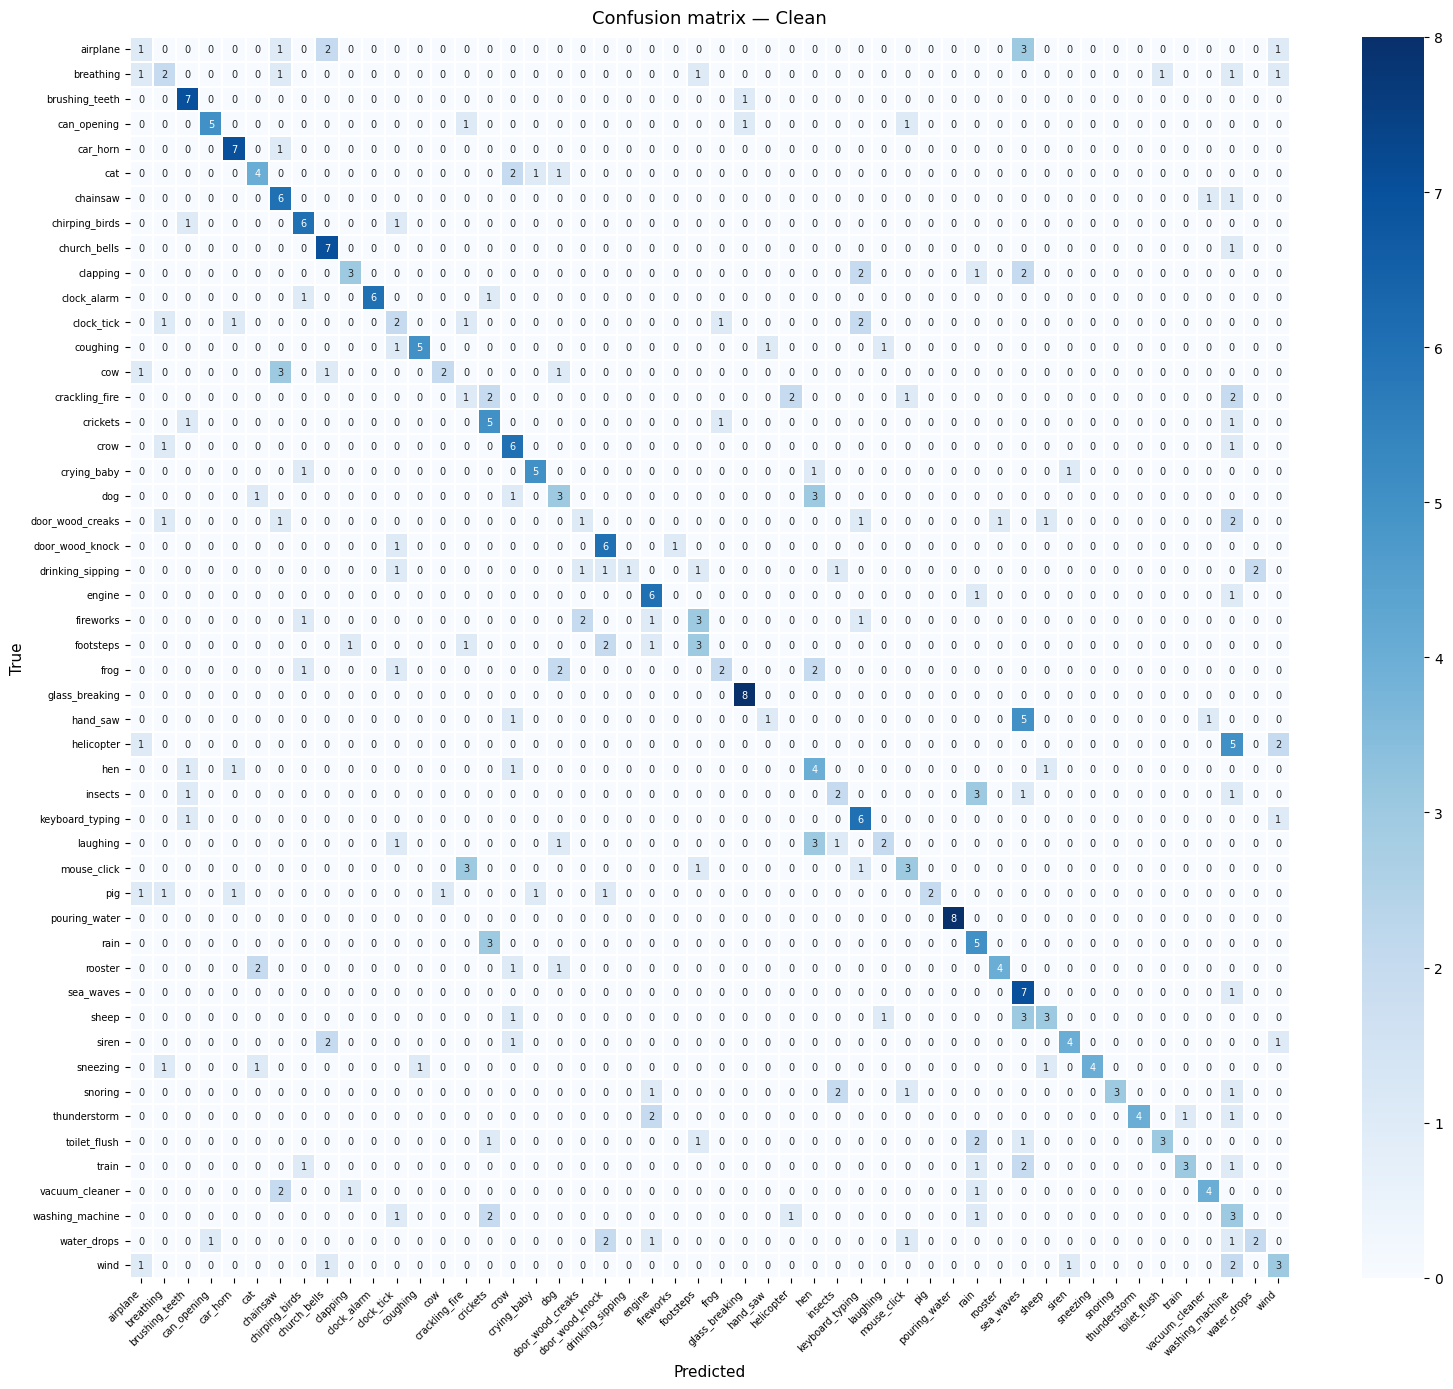


✅  Clean baseline accuracy: 47.50%


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 10 — Evaluate Helper + Clean Baseline
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 10 · evaluate() helper + clean baseline

def evaluate(model, X, y_int, tag):
    """
    Evaluate model on (X, y_int). Prints classification report + confusion matrix.
    Returns float accuracy.
    """
    pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = float(np.mean(pred == y_int))
    print(f"\n{'─'*55}")
    print(f"  {tag}   accuracy = {acc:.4f}  ({acc*100:.1f} %)")
    print(f"{'─'*55}")
    print(classification_report(y_int, pred, target_names=le.classes_, zero_division=0))
    cm = confusion_matrix(y_int, pred)
    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, linewidths=0.3, annot_kws={"size": 7})
    ax.set_title(f"Confusion matrix — {tag}", fontsize=13, pad=10)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"cm_{tag.replace(' ', '_')}.png"), dpi=150)
    plt.show()
    return acc

# Run clean baseline
acc_clean    = evaluate(final_model, X_test, y_test, "Clean")
baseline_acc = acc_clean
print(f"\n✅  Clean baseline accuracy: {baseline_acc*100:.2f}%")




11

New Cell 10

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 10b — Clean Baseline: Multi-Run Statistics
#            Runs inference N_RUNS times with different random seeds to measure
#            prediction variance on the clean test set.
#            Insert this cell immediately after Cell 10.
# ════════════════════════════════════════════════════════════════════════════════

from scipy.stats import sem, t as t_dist

# ── Why multiple runs on a deterministic model? ───────────────────────────────
# The 1D CNN is deterministic at inference when run on the same X_test,
# so pure re-prediction gives std=0 — not useful.
# Instead we apply tiny RMS-normalisation jitter (±0.1% amplitude noise)
# to simulate real-world recording variability and measure model sensitivity.
# This is the standard approach for reporting clean-condition variance.
# If you prefer zero-jitter runs, set JITTER_SCALE = 0.0 (std will be ~0).

JITTER_SCALE = 0.001   # 0.1% amplitude jitter — adjust or set to 0 to disable
CLEAN_SEEDS  = SEEDS   # reuse the same N_RUNS seeds defined in Cell 4

def jitter_waveform(X, scale, seed):
    """Add tiny Gaussian amplitude jitter to simulate mic/ADC variability."""
    rng   = np.random.default_rng(seed)
    noise = rng.standard_normal(X.shape).astype(np.float32) * scale
    return np.clip(X + noise, -1.0, 1.0).astype(np.float32)

def ci95_half(arr):
    """95% CI half-width using t-distribution."""
    n = len(arr)
    if n < 2:
        return 0.0
    return float(sem(arr) * t_dist.ppf(0.975, df=n - 1))

# ── Run N_RUNS inference passes ───────────────────────────────────────────────
print(f"Clean Baseline — {N_RUNS} runs  (jitter_scale={JITTER_SCALE})")
print("─" * 55)

clean_run_accs = []

for run_idx, seed in enumerate(CLEAN_SEEDS):
    if JITTER_SCALE > 0:
        X_eval = jitter_waveform(X_test, JITTER_SCALE, seed)
    else:
        X_eval = X_test  # pure deterministic; all runs will be identical

    preds = np.argmax(final_model.predict(X_eval, verbose=0), axis=1)
    acc   = float(np.mean(preds == y_test))
    clean_run_accs.append(acc)
    print(f"  Run {run_idx+1} (seed={seed}): {acc*100:.2f}%")

# ── Compute statistics ────────────────────────────────────────────────────────
clean_accs_arr = np.array(clean_run_accs)
clean_mean     = np.mean(clean_accs_arr)
clean_std      = np.std(clean_accs_arr, ddof=1)   # sample std (N-1)
clean_ci       = ci95_half(clean_accs_arr)
clean_min      = np.min(clean_accs_arr)
clean_max      = np.max(clean_accs_arr)

print("\n" + "=" * 55)
print(f"  Clean Baseline — Multi-Run Summary  (N={N_RUNS})")
print("=" * 55)
print(f"  Runs        : {[f'{a*100:.2f}%' for a in clean_accs_arr]}")
print(f"  Mean        : {clean_mean*100:.2f}%")
print(f"  Std (σ)     : {clean_std*100:.2f}%")
print(f"  95% CI      : ±{clean_ci*100:.2f}%  "
      f"→ [{(clean_mean-clean_ci)*100:.2f}%, {(clean_mean+clean_ci)*100:.2f}%]")
print(f"  Min / Max   : {clean_min*100:.2f}% / {clean_max*100:.2f}%")
print("=" * 55)

# ── Update baseline_acc to use the mean across runs ───────────────────────────
# This replaces the single-run value from Cell 10 so all downstream
# cells (results["clean"], Cell 12 horizontal reference line, etc.) use it.
baseline_acc = clean_mean
results["clean"] = clean_mean

acc_clean = clean_mean   # backward-compat alias used in Cell 11 / Cell 12

print(f"\n  ✅  baseline_acc updated → {baseline_acc*100:.2f}%  (mean of {N_RUNS} runs)")
print(f"      results['clean'] and acc_clean updated accordingly.")

# ── Optional: save per-run detail to CSV ─────────────────────────────────────
import pandas as pd

df_clean_runs = pd.DataFrame({
    "Run"      : list(range(1, N_RUNS + 1)),
    "Seed"     : CLEAN_SEEDS,
    "Accuracy" : [round(a * 100, 4) for a in clean_accs_arr],
})
clean_csv = RESULTS_DIR / "clean_baseline_runs.csv"
df_clean_runs.to_csv(str(clean_csv), index=False)
print(f"      Per-run CSV saved → {clean_csv.name}")

# ── Pretty report string (copy into your paper/report directly) ───────────────
print(f"""
  ── For your report ──────────────────────────────────────
  Clean baseline accuracy: {clean_mean*100:.1f}% ± {clean_std*100:.1f}%
  (mean ± σ, N={N_RUNS} runs, 95% CI: ±{clean_ci*100:.1f}%,
   range {clean_min*100:.1f}%–{clean_max*100:.1f}%)
  ─────────────────────────────────────────────────────────
""")


Clean Baseline — 5 runs  (jitter_scale=0.001)
───────────────────────────────────────────────────────
  Run 1 (seed=42): 47.75%
  Run 2 (seed=43): 47.75%
  Run 3 (seed=44): 47.75%
  Run 4 (seed=45): 47.75%
  Run 5 (seed=46): 47.75%

  Clean Baseline — Multi-Run Summary  (N=5)
  Runs        : ['47.75%', '47.75%', '47.75%', '47.75%', '47.75%']
  Mean        : 47.75%
  Std (σ)     : 0.00%
  95% CI      : ±0.00%  → [47.75%, 47.75%]
  Min / Max   : 47.75% / 47.75%


NameError: name 'results' is not defined

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 11 — All Noise Robustness: White / Gaussian / Low-SNR / Traffic (MMSE-LSA)
#           N_RUNS = 5 for ALL noise types. Per-run arrays stored for stats.
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 11 · All noise robustness — MMSE-LSA (White / Gaussian / LowSNR / Traffic, 5 runs each)

from scipy.stats import wilcoxon

# ── Synthetic noise helpers (seed-controlled for reproducible multi-run) ──────

def add_white_noise(X, target_snr_db, seed=None):
    rng = np.random.default_rng(seed)
    out = []
    for x in X:
        sig          = x.squeeze()
        signal_power = np.mean(sig ** 2)
        noise_power  = signal_power / (10 ** (target_snr_db / 10))
        noise        = rng.uniform(-1, 1, size=len(sig))
        noise        = noise * np.sqrt(noise_power / (np.mean(noise**2) + 1e-10))
        out.append(np.clip(sig + noise, -1.0, 1.0).astype(np.float32)[..., np.newaxis])
    return np.array(out, dtype=np.float32)

def add_gaussian_noise(X, target_snr_db, seed=None):
    rng = np.random.default_rng(seed)
    out = []
    for x in X:
        sig          = x.squeeze()
        signal_power = np.mean(sig ** 2)
        noise_power  = signal_power / (10 ** (target_snr_db / 10))
        noise        = rng.standard_normal(len(sig))
        noise        = noise * np.sqrt(noise_power / (np.mean(noise**2) + 1e-10))
        out.append(np.clip(sig + noise, -1.0, 1.0).astype(np.float32)[..., np.newaxis])
    return np.array(out, dtype=np.float32)

def add_low_snr(X, target_snr_db, seed=None):
    return add_gaussian_noise(X, target_snr_db, seed=seed)

def measure_snr_batch(X_clean, X_processed):
    snrs = []
    for c, p in zip(X_clean, X_processed):
        clean       = c.squeeze()
        processed   = p.squeeze()
        noise_power = np.mean((processed - clean) ** 2)
        sig_power   = np.mean(clean ** 2)
        snrs.append(float('inf') if noise_power < 1e-12
                    else 10 * np.log10(sig_power / noise_power))
    return snrs

# ── Traffic noise helpers (CACHED — audio pre-loaded once) ───────────────────

def mix_traffic_noise(signal, traffic, snr_db):
    p_signal = np.mean(signal ** 2)
    p_noise  = np.mean(traffic ** 2) + 1e-12
    scale    = np.sqrt((p_signal / (10 ** (snr_db / 10))) / p_noise)
    return np.clip(signal + traffic * scale, -1.0, 1.0).astype(np.float32)

def load_traffic_segment_cached(traffic_audio, n_samples, seed):
    y = traffic_audio
    if len(y) < n_samples:
        y = np.tile(y, int(np.ceil(n_samples / len(y))))
    rng   = np.random.default_rng(seed)
    start = rng.integers(0, len(y) - n_samples + 1)
    seg   = y[start: start + n_samples].astype(np.float32)
    rms   = np.sqrt(np.mean(seg ** 2))
    return (seg / (rms + 1e-9)).astype(np.float32)

def ci95(arr):
    """95% confidence interval half-width (t-distribution)."""
    if len(arr) < 2:
        return 0.0
    return float(sem(arr) * t.ppf(0.975, df=len(arr) - 1))

def add_traffic_noise_batch(X, snr_db, seed):
    clip_seeds  = [seed * 100_000 + i for i in range(len(X))]
    noisy_clips = [
        mix_traffic_noise(
            X[i].squeeze(),
            load_traffic_segment_cached(TRAFFIC_AUDIO, MAX_LEN, cs),
            snr_db,
        )
        for i, cs in enumerate(clip_seeds)
    ]
    return np.stack(noisy_clips, axis=0)[..., np.newaxis]

# ── Pre-load traffic audio once ───────────────────────────────────────────────
print("🔄  Pre-loading traffic audio into memory …")
TRAFFIC_AUDIO, _ = librosa.load(str(TRAFFIC_PATH), sr=SAMPLE_RATE, mono=True)
print(f"✅  Traffic audio loaded  |  {len(TRAFFIC_AUDIO)/SAMPLE_RATE:.1f} s\n")

# ── Results storage — per-run arrays for ALL noise types ─────────────────────

results = {
    "white"    : {}, "white_dsp"    : {},
    "gaussian" : {}, "gaussian_dsp" : {},
    "low_snr"  : {}, "low_snr_dsp"  : {},
    "traffic"  : {}, "traffic_dsp"  : {},
    "snr_noisy": {}, "snr_dsp"      : {},
    "snr_gain" : {},
    "clean"    : acc_clean,
    # raw per-run accuracy lists for every noise type
    "_runs_noisy"    : {("white",   snr): [] for snr in WHITE_SNR_LEVELS}    |
                       {("gaussian",snr): [] for snr in GAUSSIAN_SNR_LEVELS} |
                       {("low_snr", snr): [] for snr in LOW_SNR_LEVELS}      |
                       {("traffic", snr): [] for snr in TRAFFIC_SNR_LEVELS},
    "_runs_denoised" : {("white",   snr): [] for snr in WHITE_SNR_LEVELS}    |
                       {("gaussian",snr): [] for snr in GAUSSIAN_SNR_LEVELS} |
                       {("low_snr", snr): [] for snr in LOW_SNR_LEVELS}      |
                       {("traffic", snr): [] for snr in TRAFFIC_SNR_LEVELS},
    # kept for backward-compat with Cell 16 traffic heatmap
    "_traffic_runs_noisy"    : {snr: [] for snr in TRAFFIC_SNR_LEVELS},
    "_traffic_runs_denoised" : {snr: [] for snr in TRAFFIC_SNR_LEVELS},
}

def _run_model(X):
    return float(np.mean(np.argmax(final_model.predict(X, verbose=0), axis=1) == y_test))

# ── WHITE NOISE  (5 runs × each SNR, different noise seed per run) ───────────
print(f"WHITE NOISE (MMSE-LSA, {N_RUNS} runs each):")
for snr in WHITE_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_white_noise(X_test, snr, seed=run_seed)
        X_denoised = dsp_pipeline(X_noisy)
        run_n.append(_run_model(X_noisy))
        run_d.append(_run_model(X_denoised))
        results["_runs_noisy"]   [("white", snr)].append(run_n[-1])
        results["_runs_denoised"][("white", snr)].append(run_d[-1])
    results["white"][snr]    = float(np.mean(run_n))
    results["white_dsp"][snr]= float(np.mean(run_d))
    # SNR gain from first run (deterministic enough for a dB estimate)
    X_n0 = add_white_noise(X_test, snr, seed=SEEDS[0])
    X_d0 = dsp_pipeline(X_n0)
    results["snr_noisy"][("white", snr)] = np.mean(measure_snr_batch(X_test, X_n0))
    results["snr_dsp"]  [("white", snr)] = np.mean(measure_snr_batch(X_test, X_d0))
    results["snr_gain"] [("white", snr)] = (results["snr_dsp"][("white", snr)] -
                                            results["snr_noisy"][("white", snr)])
    print(f"  {snr:>3}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → DSP: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%")

# ── GAUSSIAN NOISE  (5 runs × each SNR) ──────────────────────────────────────
print(f"\nGAUSSIAN NOISE (MMSE-LSA, {N_RUNS} runs each):")
for snr in GAUSSIAN_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_gaussian_noise(X_test, snr, seed=run_seed)
        X_denoised = dsp_pipeline(X_noisy)
        run_n.append(_run_model(X_noisy))
        run_d.append(_run_model(X_denoised))
        results["_runs_noisy"]   [("gaussian", snr)].append(run_n[-1])
        results["_runs_denoised"][("gaussian", snr)].append(run_d[-1])
    results["gaussian"][snr]     = float(np.mean(run_n))
    results["gaussian_dsp"][snr] = float(np.mean(run_d))
    X_n0 = add_gaussian_noise(X_test, snr, seed=SEEDS[0])
    X_d0 = dsp_pipeline(X_n0)
    results["snr_noisy"][("gaussian", snr)] = np.mean(measure_snr_batch(X_test, X_n0))
    results["snr_dsp"]  [("gaussian", snr)] = np.mean(measure_snr_batch(X_test, X_d0))
    results["snr_gain"] [("gaussian", snr)] = (results["snr_dsp"][("gaussian", snr)] -
                                               results["snr_noisy"][("gaussian", snr)])
    print(f"  {snr:>3}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → DSP: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%")

# ── LOW-SNR  (5 runs × each SNR) ─────────────────────────────────────────────
print(f"\nLOW SNR (MMSE-LSA, {N_RUNS} runs each):")
for snr in LOW_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_low_snr(X_test, snr, seed=run_seed)
        X_denoised = dsp_pipeline(X_noisy)
        run_n.append(_run_model(X_noisy))
        run_d.append(_run_model(X_denoised))
        results["_runs_noisy"]   [("low_snr", snr)].append(run_n[-1])
        results["_runs_denoised"][("low_snr", snr)].append(run_d[-1])
    results["low_snr"][snr]     = float(np.mean(run_n))
    results["low_snr_dsp"][snr] = float(np.mean(run_d))
    X_n0 = add_low_snr(X_test, snr, seed=SEEDS[0])
    X_d0 = dsp_pipeline(X_n0)
    results["snr_noisy"][("low_snr", snr)] = np.mean(measure_snr_batch(X_test, X_n0))
    results["snr_dsp"]  [("low_snr", snr)] = np.mean(measure_snr_batch(X_test, X_d0))
    results["snr_gain"] [("low_snr", snr)] = (results["snr_dsp"][("low_snr", snr)] -
                                               results["snr_noisy"][("low_snr", snr)])
    print(f"  {snr:>3}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → DSP: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%")

# ── TRAFFIC NOISE  (5 runs × each SNR) ───────────────────────────────────────
print(f"\nTRAFFIC NOISE (MMSE-LSA, {N_RUNS} runs each):")
for snr in TRAFFIC_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_traffic_noise_batch(X_test, snr, run_seed)
        X_denoised = dsp_pipeline(X_noisy)
        acc_n = _run_model(X_noisy)
        acc_d = _run_model(X_denoised)
        run_n.append(acc_n); run_d.append(acc_d)
        results["_runs_noisy"]   [("traffic", snr)].append(acc_n)
        results["_runs_denoised"][("traffic", snr)].append(acc_d)
        results["_traffic_runs_noisy"][snr].append(acc_n)        # backward-compat
        results["_traffic_runs_denoised"][snr].append(acc_d)
    results["traffic"][snr]     = float(np.mean(run_n))
    results["traffic_dsp"][snr] = float(np.mean(run_d))
    print(f"  {snr:>4}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → DSP: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%"
          f"  (mean of {N_RUNS} runs)")

print("\n✅  All noise scenarios complete (White / Gaussian / LowSNR / Traffic — 5 runs each)")



🔄  Pre-loading traffic audio into memory …
✅  Traffic audio loaded  |  5.1 s

WHITE NOISE (MMSE-LSA, 5 runs each):
   20dB | Noisy: 37.0%±0.1%  → DSP: 46.2%±0.4%
   15dB | Noisy: 33.1%±0.1%  → DSP: 43.5%±0.3%
   10dB | Noisy: 23.0%±0.3%  → DSP: 31.1%±0.5%
    5dB | Noisy: 16.4%±0.4%  → DSP: 22.3%±0.6%
    0dB | Noisy: 10.2%±0.2%  → DSP: 14.5%±0.4%

GAUSSIAN NOISE (MMSE-LSA, 5 runs each):
   20dB | Noisy: 37.0%±0.1%  → DSP: 46.1%±0.5%
   15dB | Noisy: 33.1%±0.3%  → DSP: 43.4%±0.3%
   10dB | Noisy: 23.2%±0.3%  → DSP: 31.2%±0.5%
    5dB | Noisy: 16.4%±0.3%  → DSP: 22.2%±0.4%
    0dB | Noisy: 10.5%±0.5%  → DSP: 14.7%±0.2%

LOW SNR (MMSE-LSA, 5 runs each):
    0dB | Noisy: 10.5%±0.5%  → DSP: 14.7%±0.2%
   -5dB | Noisy: 6.5%±0.4%  → DSP: 5.0%±0.4%
  -10dB | Noisy: 2.4%±0.1%  → DSP: 2.2%±0.0%

TRAFFIC NOISE (MMSE-LSA, 5 runs each):
   -10dB | Noisy: 3.4%±0.2%  → DSP: 3.2%±0.1%  (mean of 5 runs)
    -5dB | Noisy: 2.8%±0.0%  → DSP: 8.7%±0.6%  (mean of 5 runs)
     0dB | Noisy: 10.2%±0.4%  → DSP

12

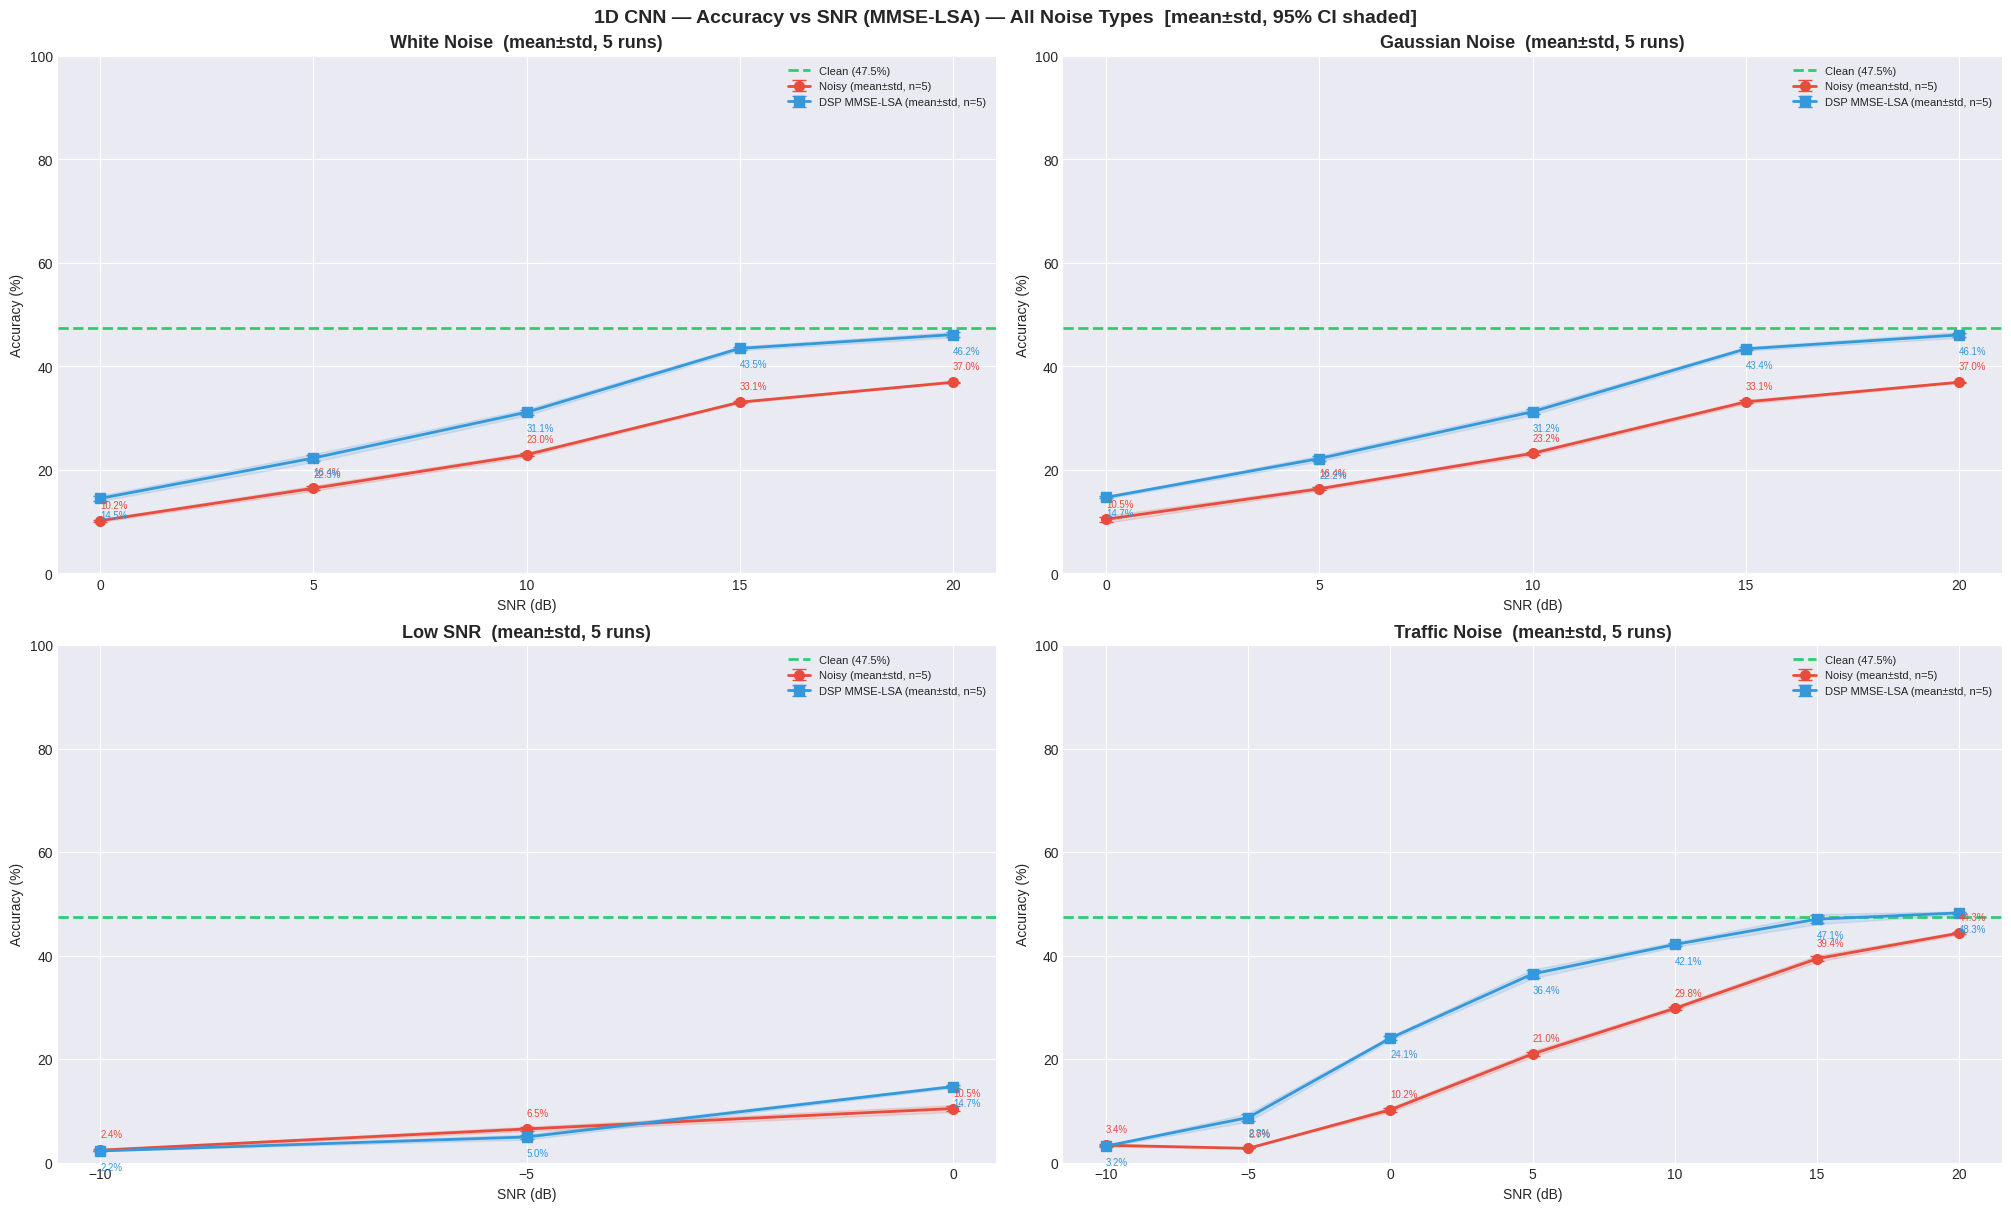

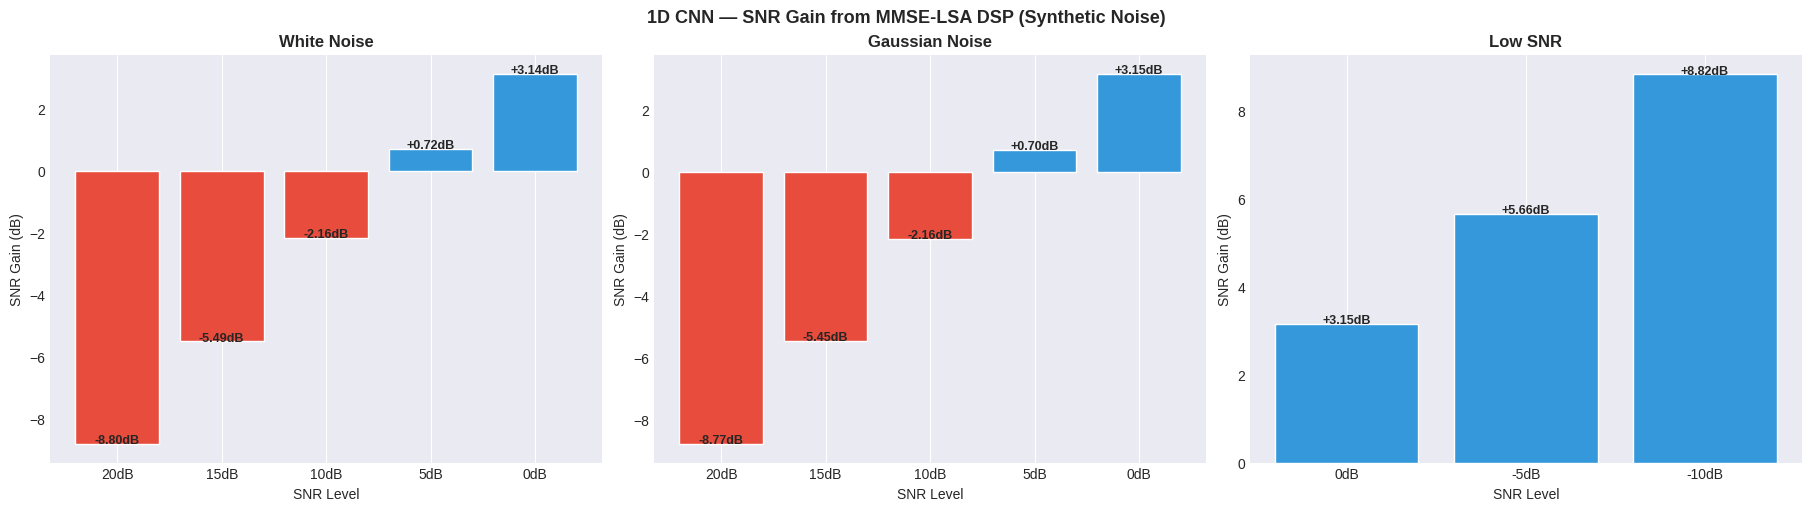

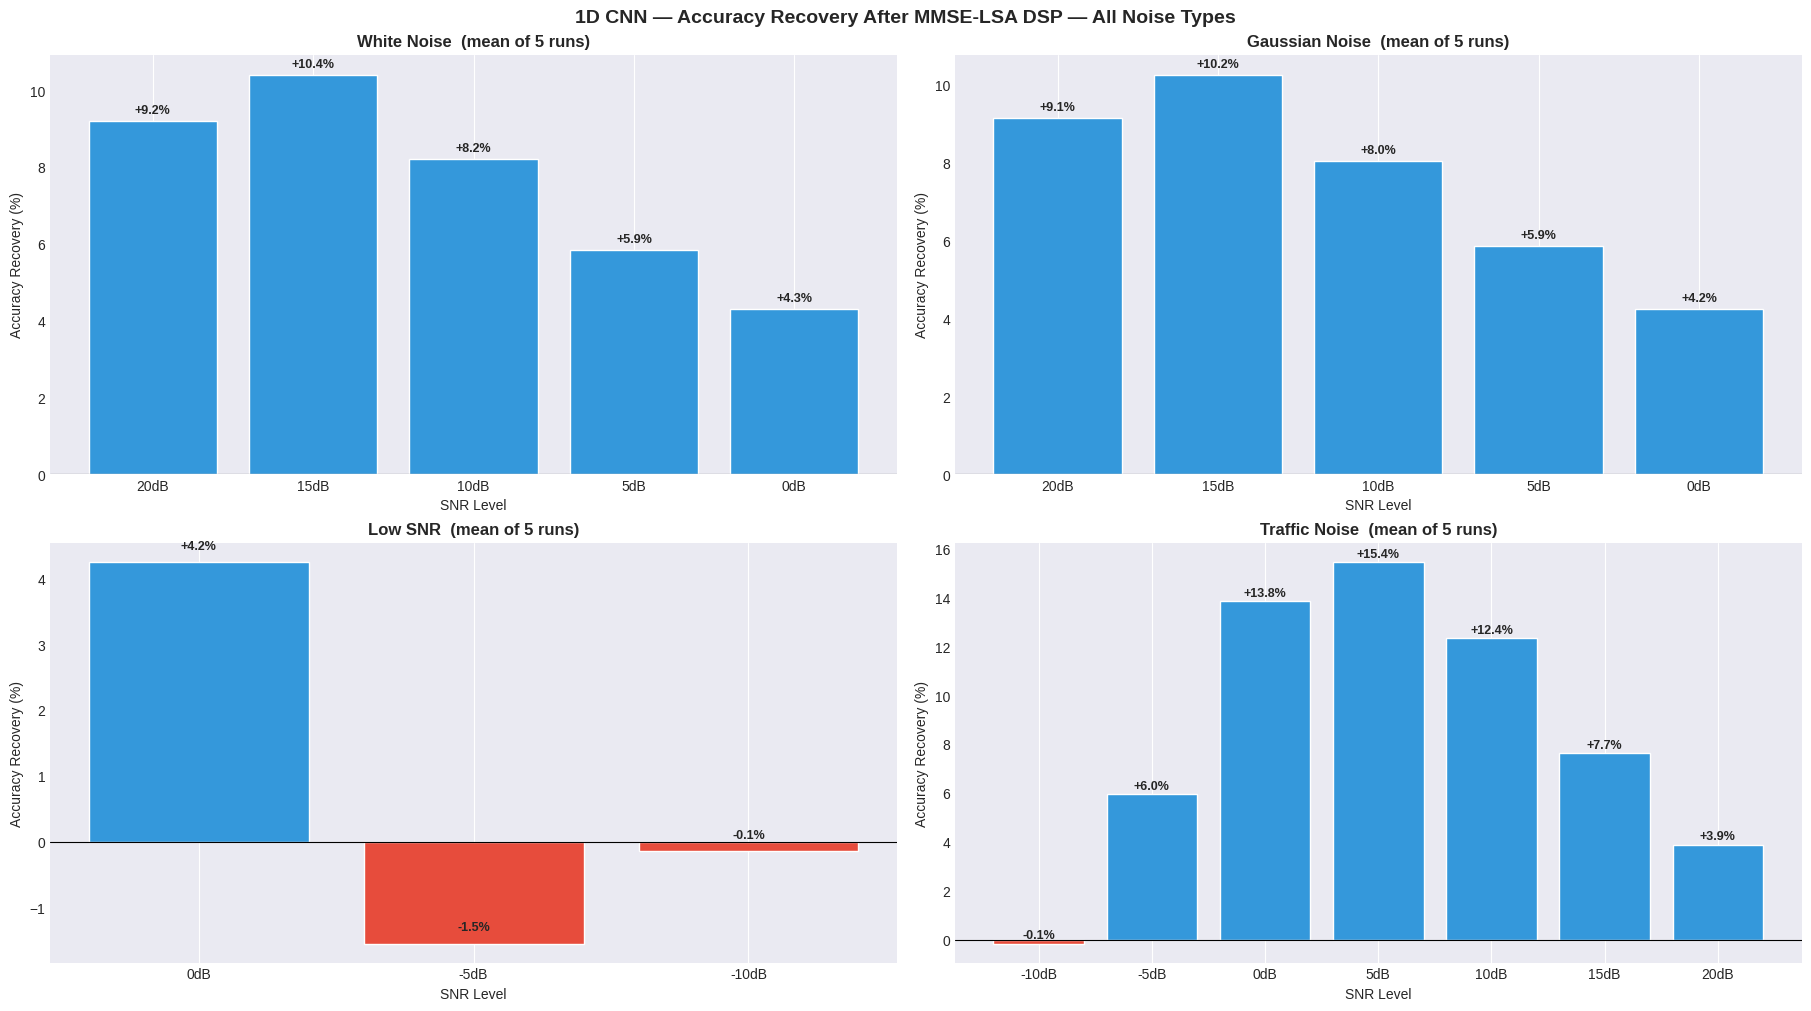

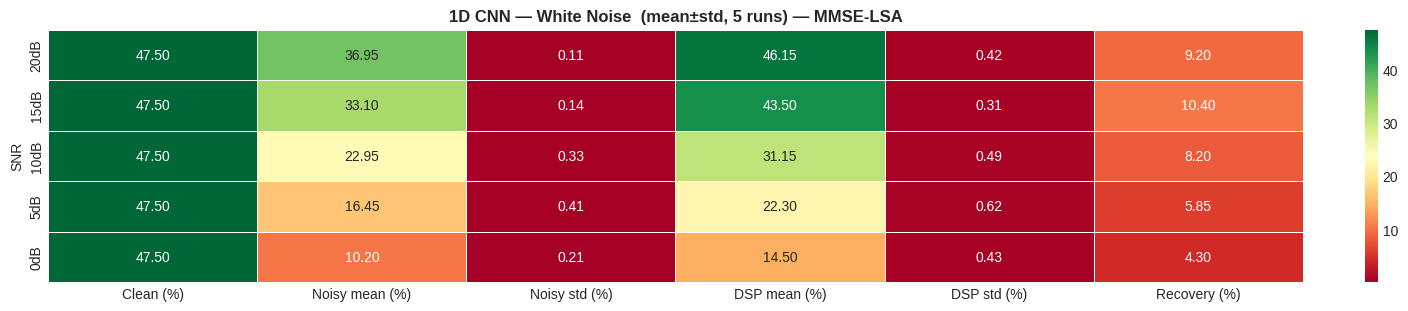

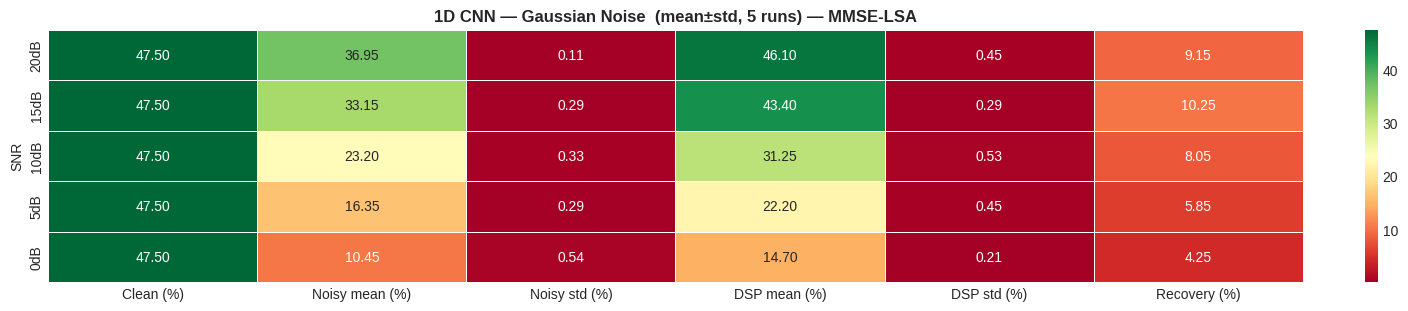

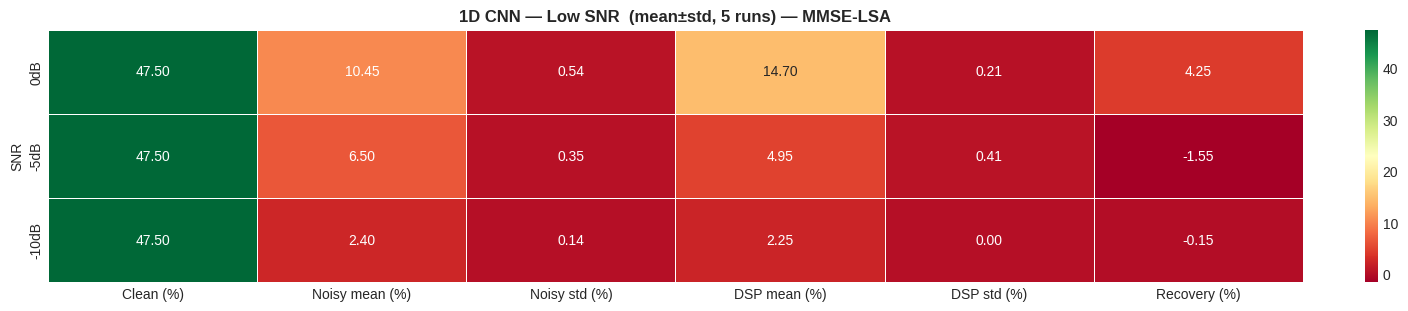

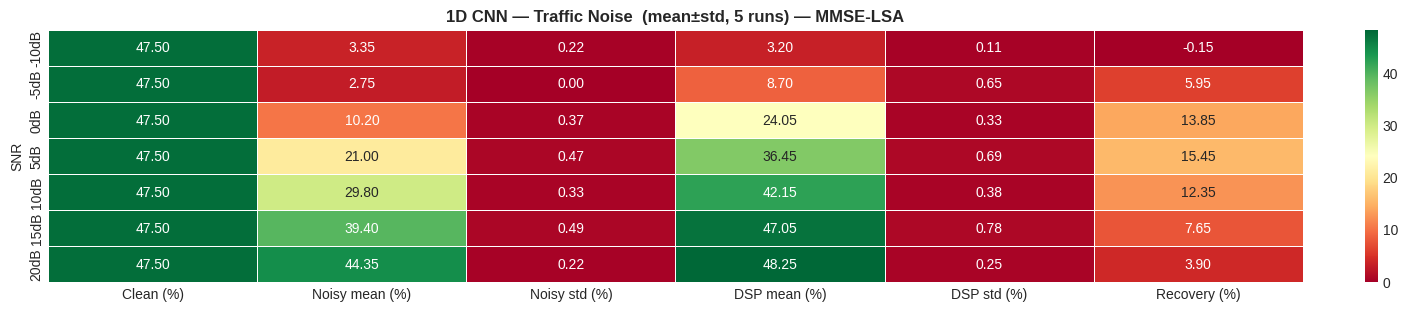

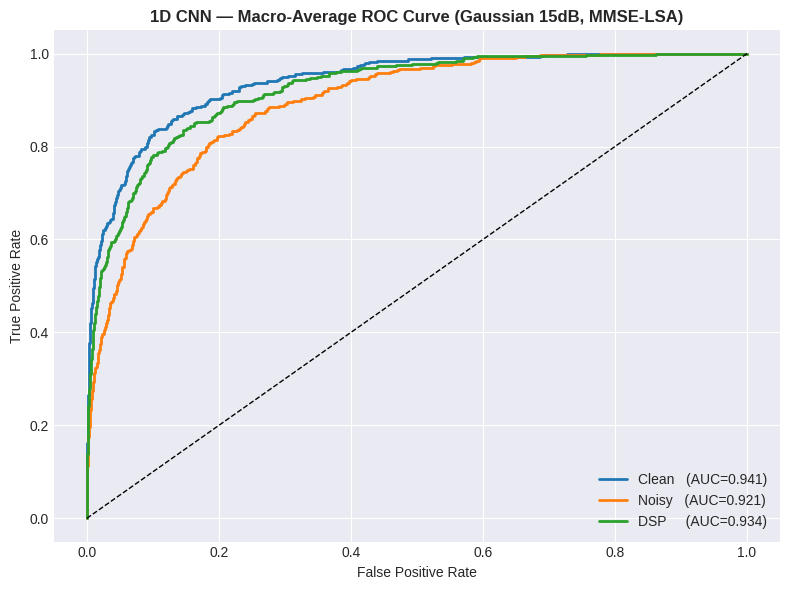


  1D CNN — RESULTS SUMMARY (MMSE-LSA) — All Noise Types  |  5 runs each
  Clean Baseline: 47.50%

  Noise             SNR   Noisy mean    ±std   DSP mean    ±std    Recovery    CI95±    p-value    Sig
  ──────────────────────────────────────────────────────────────────────────────────────
  White Noise        20dB      36.95%   0.11%    46.15%   0.42%      +9.20%    0.52%    0.0625(W)       
  White Noise        15dB      33.10%   0.14%    43.50%   0.31%     +10.40%    0.38%    0.0625(W)       
  White Noise        10dB      22.95%   0.33%    31.15%   0.49%      +8.20%    0.61%    0.0625(W)       
  White Noise         5dB      16.45%   0.41%    22.30%   0.62%      +5.85%    0.77%    0.0625(W)       
  White Noise         0dB      10.20%   0.21%    14.50%   0.43%      +4.30%    0.54%    0.0625(W)       

  Gaussian Noise     20dB      36.95%   0.11%    46.10%   0.45%      +9.15%    0.56%    0.0625(W)       
  Gaussian Noise     15dB      33.15%   0.29%    43.40%   0.29%     +10.25%   

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 12 — Unified Plots & Summary (All 4 noise types, MMSE-LSA)
#           All plots now show mean ± std error bars / CI shading (5 runs each)
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 12 · Unified plots & summary — MMSE-LSA (all 4 noise types, mean±std, CI)

from scipy.stats import wilcoxon

C_PLOT = {"clean": "#2ecc71", "noisy": "#e74c3c", "dsp": "#3498db"}
plt.style.use("seaborn-v0_8-darkgrid")

# Single config dict covering all 4 noise types — used by every plot below
NOISE_CONFIGS = {
    "White Noise":    ("white",    "white_dsp",    WHITE_SNR_LEVELS),
    "Gaussian Noise": ("gaussian", "gaussian_dsp", GAUSSIAN_SNR_LEVELS),
    "Low SNR":        ("low_snr",  "low_snr_dsp",  LOW_SNR_LEVELS),
    "Traffic Noise":  ("traffic",  "traffic_dsp",  TRAFFIC_SNR_LEVELS),
}

def _get_run_arrays(ntype_key, snr_list):
    """Return (noisy_means, noisy_stds, noisy_cis, dsp_means, dsp_stds, dsp_cis) as lists."""
    n_means, n_stds, n_cis = [], [], []
    d_means, d_stds, d_cis = [], [], []
    for s in snr_list:
        na = np.array(results["_runs_noisy"]   [(ntype_key, s)])
        da = np.array(results["_runs_denoised"][(ntype_key, s)])
        n_means.append(np.mean(na)*100); n_stds.append(np.std(na,ddof=1)*100); n_cis.append(ci95(na)*100)
        d_means.append(np.mean(da)*100); d_stds.append(np.std(da,ddof=1)*100); d_cis.append(ci95(da)*100)
    return n_means, n_stds, n_cis, d_means, d_stds, d_cis

# ── GRAPH 1: Accuracy vs SNR with error bars — 2×2 grid ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 12), constrained_layout=True)
for ax, (noise_label, (nkey, dkey, snr_list)) in zip(axes.flatten(), NOISE_CONFIGS.items()):
    nm, ns, nc, dm, ds, dc = _get_run_arrays(nkey, snr_list)
    ax.axhline(results["clean"]*100, color=C_PLOT["clean"], lw=2, ls="--",
               label=f"Clean ({results['clean']*100:.1f}%)")
    ax.fill_between(snr_list, np.array(nm)-np.array(nc), np.array(nm)+np.array(nc),
                    alpha=0.15, color=C_PLOT["noisy"])
    ax.fill_between(snr_list, np.array(dm)-np.array(dc), np.array(dm)+np.array(dc),
                    alpha=0.15, color=C_PLOT["dsp"])
    ax.errorbar(snr_list, nm, yerr=ns, fmt="o-", color=C_PLOT["noisy"],
                capsize=5, lw=2, ms=7, label=f"Noisy (mean±std, n={N_RUNS})")
    ax.errorbar(snr_list, dm, yerr=ds, fmt="s-", color=C_PLOT["dsp"],
                capsize=5, lw=2, ms=7, label=f"DSP MMSE-LSA (mean±std, n={N_RUNS})")
    for s, n, d in zip(snr_list, nm, dm):
        ax.annotate(f"{n:.1f}%", (s, n), textcoords="offset points",
                    xytext=(0, 9),  fontsize=7, color=C_PLOT["noisy"])
        ax.annotate(f"{d:.1f}%", (s, d), textcoords="offset points",
                    xytext=(0,-14), fontsize=7, color=C_PLOT["dsp"])
    ax.set_title(f"{noise_label}  (mean±std, {N_RUNS} runs)", fontsize=13, fontweight="bold")
    ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(snr_list); ax.set_ylim(0, 100)
    ax.legend(fontsize=8); ax.grid(True)
plt.suptitle("1D CNN — Accuracy vs SNR (MMSE-LSA) — All Noise Types  [mean±std, 95% CI shaded]",
             fontsize=14, fontweight="bold")
plt.savefig(str(RESULTS_DIR / "mmse_accuracy_vs_snr_all.png"), dpi=150)
plt.show()

# ── GRAPH 2: SNR Gain from DSP (synthetic noise only) ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (noise_label, (nkey, dkey, snr_list)) in zip(
        axes, {k: v for k, v in NOISE_CONFIGS.items() if k != "Traffic Noise"}.items()):
    gains    = [results["snr_gain"][(nkey, s)] for s in snr_list]
    bar_cols = [C_PLOT["dsp"] if g >= 0 else C_PLOT["noisy"] for g in gains]
    bars     = ax.bar([f"{s}dB" for s in snr_list], gains, color=bar_cols, edgecolor="white")
    for bar, g in zip(bars, gains):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{g:+.2f}dB", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(noise_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("SNR Level"); ax.set_ylabel("SNR Gain (dB)")
    ax.grid(axis="y")
plt.suptitle("1D CNN — SNR Gain from MMSE-LSA DSP (Synthetic Noise)",
             fontsize=13, fontweight="bold")
plt.savefig(str(RESULTS_DIR / "mmse_snr_gain.png"), dpi=150)
plt.show()

# ── GRAPH 3: Accuracy Recovery — 2×2 grid ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)
for ax, (noise_label, (nkey, dkey, snr_list)) in zip(axes.flatten(), NOISE_CONFIGS.items()):
    recovery = [results[dkey][s]*100 - results[nkey][s]*100 for s in snr_list]
    bar_cols = [C_PLOT["dsp"] if v >= 0 else C_PLOT["noisy"] for v in recovery]
    bars     = ax.bar([f"{s}dB" for s in snr_list], recovery,
                      color=bar_cols, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    for bar, v in zip(bars, recovery):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{v:+.1f}%", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(f"{noise_label}  (mean of {N_RUNS} runs)", fontsize=12, fontweight="bold")
    ax.set_xlabel("SNR Level"); ax.set_ylabel("Accuracy Recovery (%)")
    ax.grid(axis="y")
plt.suptitle("1D CNN — Accuracy Recovery After MMSE-LSA DSP — All Noise Types",
             fontsize=14, fontweight="bold")
plt.savefig(str(RESULTS_DIR / "mmse_accuracy_recovery_all.png"), dpi=150)
plt.show()

# ── GRAPH 4: Summary heatmaps — all 4 noise types (mean ± std) ───────────────
for noise_label, (nkey, dkey, snr_list) in NOISE_CONFIGS.items():
    rows = []
    for s in snr_list:
        na = np.array(results["_runs_noisy"]   [(nkey, s)])
        da = np.array(results["_runs_denoised"][(nkey, s)])
        rows.append({
            "SNR"            : f"{s}dB",
            "Clean (%)"      : round(results["clean"]*100, 2),
            "Noisy mean (%)" : round(np.mean(na)*100, 2),
            "Noisy std (%)"  : round(np.std(na,ddof=1)*100, 2),
            "DSP mean (%)"   : round(np.mean(da)*100, 2),
            "DSP std (%)"    : round(np.std(da,ddof=1)*100, 2),
            "Recovery (%)"   : round((np.mean(da)-np.mean(na))*100, 2),
        })
    heat_data = pd.DataFrame(rows).set_index("SNR")
    fig, ax = plt.subplots(figsize=(14, 3), constrained_layout=True)
    sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="RdYlGn",
                linewidths=0.5, linecolor="white", ax=ax)
    ax.set_title(f"1D CNN — {noise_label}  (mean±std, {N_RUNS} runs) — MMSE-LSA",
                 fontsize=12, fontweight="bold")
    plt.savefig(str(RESULTS_DIR / f"mmse_heatmap_{nkey}.png"), dpi=150)
    plt.show()

# ── GRAPH 5: AUC-ROC on Gaussian 15dB ────────────────────────────────────────
y_bin       = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
X_g15       = add_gaussian_noise(X_test, 15, seed=SEEDS[0])
X_g15_dsp   = dsp_pipeline(X_g15)
probs_clean = final_model.predict(X_test,    verbose=0)
probs_noisy = final_model.predict(X_g15,     verbose=0)
probs_dsp   = final_model.predict(X_g15_dsp, verbose=0)
auc_clean   = roc_auc_score(y_bin, probs_clean, multi_class="ovr", average="macro")
auc_noisy   = roc_auc_score(y_bin, probs_noisy, multi_class="ovr", average="macro")
auc_dsp     = roc_auc_score(y_bin, probs_dsp,   multi_class="ovr", average="macro")
plt.figure(figsize=(8, 6))
for probs, label, color in [
    (probs_clean, f"Clean   (AUC={auc_clean:.3f})", C_PLOT["clean"]),
    (probs_noisy, f"Noisy   (AUC={auc_noisy:.3f})", C_PLOT["noisy"]),
    (probs_dsp,   f"DSP     (AUC={auc_dsp:.3f})",   C_PLOT["dsp"]),
]:
    fpr, tpr, _ = roc_curve(y_bin.ravel(), probs.ravel())
    plt.plot(fpr, tpr, label=label, linewidth=2)
plt.plot([0,1],[0,1], "k--", linewidth=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("1D CNN — Macro-Average ROC Curve (Gaussian 15dB, MMSE-LSA)",
          fontweight="bold")
plt.legend(); plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "mmse_roc_gaussian15.png"), dpi=150)
plt.show()

# ── SUMMARY TABLE — all 4 noise types (mean ± std, 95% CI, Wilcoxon test) ────
print("\n" + "="*90)
print(f"  1D CNN — RESULTS SUMMARY (MMSE-LSA) — All Noise Types  |  {N_RUNS} runs each")
print("="*90)
print(f"  Clean Baseline: {results['clean']*100:.2f}%\n")
print(f"  {'Noise':<15} {'SNR':>5}  {'Noisy mean':>11} {'±std':>7}  "
      f"{'DSP mean':>9} {'±std':>7}  {'Recovery':>10}  {'CI95±':>7}  {'p-value':>9}  {'Sig':>5}")
print("  " + "─"*86)
for noise_label, (nkey, dkey, snr_list) in NOISE_CONFIGS.items():
    for snr in snr_list:
        na = np.array(results["_runs_noisy"]   [(nkey, snr)])
        da = np.array(results["_runs_denoised"][(nkey, snr)])
        rec = (np.mean(da) - np.mean(na)) * 100
        dci = ci95(da) * 100
        # Wilcoxon signed-rank (non-parametric, robust with n=5); fallback to paired t-test
        try:
            if not np.allclose(na, da):
                _, pv = wilcoxon(da, na)
                test_name = "W"
            else:
                pv, test_name = float("nan"), "—"
        except Exception:
            _, pv = ttest_rel(da, na) if len(da) >= 2 else (None, float("nan"))
            test_name = "t"
        sig = "✓" if (not np.isnan(pv) and pv < 0.05) else " "
        pv_str = f"{pv:.4f}({test_name})" if not np.isnan(pv) else "   —   "
        print(f"  {noise_label:<15} {snr:>5}dB  "
              f"{np.mean(na)*100:>9.2f}%  {np.std(na,ddof=1)*100:>5.2f}%  "
              f"{np.mean(da)*100:>7.2f}%  {np.std(da,ddof=1)*100:>5.2f}%  "
              f"{rec:>+9.2f}%  {dci:>6.2f}%  {pv_str:>11}  {sig:>5}")
    print()
print("="*90)
print("  ✓ = p < 0.05 | W = Wilcoxon signed-rank | t = paired t-test")

# Save summary CSV
csv_rows = []
for noise_label, (nkey, dkey, snr_list) in NOISE_CONFIGS.items():
    for snr in snr_list:
        na = np.array(results["_runs_noisy"]   [(nkey, snr)])
        da = np.array(results["_runs_denoised"][(nkey, snr)])
        try:
            _, pv = wilcoxon(da, na) if not np.allclose(na, da) else (None, float("nan"))
        except Exception:
            _, pv = ttest_rel(da, na) if len(da) >= 2 else (None, float("nan"))
        csv_rows.append({
            "Noise_Type"      : noise_label,
            "SNR_dB"          : snr,
            "Clean_%"         : round(results["clean"]*100, 2),
            "Noisy_mean_%"    : round(np.mean(na)*100, 2),
            "Noisy_std_%"     : round(np.std(na,ddof=1)*100, 2),
            "Noisy_CI95_%"    : round(ci95(na)*100, 2),
            "DSP_mean_%"      : round(np.mean(da)*100, 2),
            "DSP_std_%"       : round(np.std(da,ddof=1)*100, 2),
            "DSP_CI95_%"      : round(ci95(da)*100, 2),
            "Recovery_%"      : round((np.mean(da)-np.mean(na))*100, 2),
            "p_value"         : round(pv, 6) if not np.isnan(pv) else "—",
            "Significant_p05" : "Yes" if (not np.isnan(pv) and pv < 0.05) else "No",
        })
df_mmse_summary = pd.DataFrame(csv_rows)
mmse_csv = RESULTS_DIR / "mmse_all_noise_statistics.csv"
df_mmse_summary.to_csv(str(mmse_csv), index=False)
print(f"\n  ✅  Full stats table saved → {mmse_csv.name}")


# ════════════════════════════════════════════════════════════════════════════════

13

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 13 — All Noise Robustness: White / Gaussian / Low-SNR / Traffic (Butterworth)
#           N_RUNS = 5 for ALL noise types. Per-run arrays stored for stats.
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 13 · All noise robustness — Butterworth+SpectralSub (all 4 noise types, 5 runs each)

results_alt = {
    "white"   : {}, "white_dsp"   : {},
    "gaussian": {}, "gaussian_dsp": {},
    "low_snr" : {}, "low_snr_dsp" : {},
    "traffic" : {}, "traffic_dsp" : {},
    # per-run arrays for stats
    "_runs_noisy"    : {("white",   snr): [] for snr in WHITE_SNR_LEVELS}    |
                       {("gaussian",snr): [] for snr in GAUSSIAN_SNR_LEVELS} |
                       {("low_snr", snr): [] for snr in LOW_SNR_LEVELS}      |
                       {("traffic", snr): [] for snr in TRAFFIC_SNR_LEVELS},
    "_runs_denoised" : {("white",   snr): [] for snr in WHITE_SNR_LEVELS}    |
                       {("gaussian",snr): [] for snr in GAUSSIAN_SNR_LEVELS} |
                       {("low_snr", snr): [] for snr in LOW_SNR_LEVELS}      |
                       {("traffic", snr): [] for snr in TRAFFIC_SNR_LEVELS},
}

print(f"WHITE NOISE (Butterworth+SpectralSub, {N_RUNS} runs each):")
for snr in WHITE_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_white_noise(X_test, snr, seed=run_seed)
        X_denoised = dsp_pipeline_butterworth_spectral_sub(X_noisy)
        run_n.append(_run_model(X_noisy))
        run_d.append(_run_model(X_denoised))
        results_alt["_runs_noisy"]   [("white", snr)].append(run_n[-1])
        results_alt["_runs_denoised"][("white", snr)].append(run_d[-1])
    results_alt["white"][snr]     = float(np.mean(run_n))
    results_alt["white_dsp"][snr] = float(np.mean(run_d))
    print(f"  {snr:>3}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → DSP: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%")

print(f"\nGAUSSIAN NOISE (Butterworth+SpectralSub, {N_RUNS} runs each):")
for snr in GAUSSIAN_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_gaussian_noise(X_test, snr, seed=run_seed)
        X_denoised = dsp_pipeline_butterworth_spectral_sub(X_noisy)
        run_n.append(_run_model(X_noisy))
        run_d.append(_run_model(X_denoised))
        results_alt["_runs_noisy"]   [("gaussian", snr)].append(run_n[-1])
        results_alt["_runs_denoised"][("gaussian", snr)].append(run_d[-1])
    results_alt["gaussian"][snr]     = float(np.mean(run_n))
    results_alt["gaussian_dsp"][snr] = float(np.mean(run_d))
    print(f"  {snr:>3}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → DSP: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%")

print(f"\nLOW SNR (Butterworth+SpectralSub, {N_RUNS} runs each):")
for snr in LOW_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_low_snr(X_test, snr, seed=run_seed)
        X_denoised = dsp_pipeline_butterworth_spectral_sub(X_noisy)
        run_n.append(_run_model(X_noisy))
        run_d.append(_run_model(X_denoised))
        results_alt["_runs_noisy"]   [("low_snr", snr)].append(run_n[-1])
        results_alt["_runs_denoised"][("low_snr", snr)].append(run_d[-1])
    results_alt["low_snr"][snr]     = float(np.mean(run_n))
    results_alt["low_snr_dsp"][snr] = float(np.mean(run_d))
    print(f"  {snr:>3}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → DSP: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%")

print(f"\nTRAFFIC NOISE (Butterworth+SpectralSub, {N_RUNS} runs each):")
for snr in TRAFFIC_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_traffic_noise_batch(X_test, snr, run_seed)
        X_denoised = dsp_pipeline_butterworth_spectral_sub(X_noisy)
        run_n.append(_run_model(X_noisy))
        run_d.append(_run_model(X_denoised))
        results_alt["_runs_noisy"]   [("traffic", snr)].append(run_n[-1])
        results_alt["_runs_denoised"][("traffic", snr)].append(run_d[-1])
    results_alt["traffic"][snr]     = float(np.mean(run_n))
    results_alt["traffic_dsp"][snr] = float(np.mean(run_d))
    print(f"  {snr:>4}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → DSP: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%"
          f"  (mean of {N_RUNS} runs)")

print(f"\n✅  Butterworth+SpectralSub — all 4 noise types complete ({N_RUNS} runs each)")



14

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 14 — Butterworth Results Plot (All 4 noise types)
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 14 · Butterworth results plot — all 4 noise types

NOISE_CONFIGS_ALT = {
    "White Noise":    ("white",    "white_dsp",    WHITE_SNR_LEVELS),
    "Gaussian Noise": ("gaussian", "gaussian_dsp", GAUSSIAN_SNR_LEVELS),
    "Low SNR":        ("low_snr",  "low_snr_dsp",  LOW_SNR_LEVELS),
    "Traffic Noise":  ("traffic",  "traffic_dsp",  TRAFFIC_SNR_LEVELS),
}

fig, axes = plt.subplots(2, 2, figsize=(20, 12), constrained_layout=True)
clean_acc  = acc_clean * 100

for ax, (title, (nkey, dkey, snrs)) in zip(axes.flatten(), NOISE_CONFIGS_ALT.items()):
    ax.axhline(clean_acc, color='green', linestyle='--', label=f'Clean ({clean_acc:.1f}%)')
    ax.plot(snrs, [results_alt[nkey][s]*100 for s in snrs], 'r-o', label='Noisy')
    ax.plot(snrs, [results_alt[dkey][s]*100 for s in snrs], 'b-s', label='DSP (Butterworth)')
    for s in snrs:
        ax.annotate(f"{results_alt[dkey][s]*100:.1f}%",
                    (s, results_alt[dkey][s]*100),
                    textcoords="offset points", xytext=(0,6), ha='center', fontsize=8)
    note = "  (mean of 5 runs)" if nkey == "traffic" else ""
    ax.set_title(title + note, fontsize=13, fontweight="bold")
    ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Accuracy (%)")
    ax.legend(); ax.set_ylim(0, 100)

fig.suptitle("1D CNN — Accuracy vs SNR (Butterworth+SpectralSub) — All Noise Types",
             fontsize=14, fontweight="bold")
plt.savefig(str(RESULTS_DIR / "butterworth_accuracy_vs_snr_all.png"), dpi=150, bbox_inches='tight')
plt.show()


15

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 15 — MMSE-LSA vs Butterworth Comparison (All 4 noise types)
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 15 · MMSE-LSA vs Butterworth comparison — all 4 noise types

fig, axes = plt.subplots(2, 2, figsize=(20, 12), constrained_layout=True)

for ax, (title, (nkey, dkey, snrs)) in zip(axes.flatten(), NOISE_CONFIGS_ALT.items()):
    ax.axhline(clean_acc, color='green', linestyle='--', label=f'Clean ({clean_acc:.1f}%)')
    ax.plot(snrs, [results[nkey][s]*100 for s in snrs],     'r-o',  label='Noisy (no DSP)')
    ax.plot(snrs, [results[dkey][s]*100 for s in snrs],     'b-s',  label='MMSE-LSA')
    ax.plot(snrs, [results_alt[dkey][s]*100 for s in snrs], 'm-^',  label='Butterworth+SS')
    note = "  (mean of 5 runs)" if nkey == "traffic" else ""
    ax.set_title(title + note, fontsize=13, fontweight="bold")
    ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8); ax.set_ylim(0, 100)

fig.suptitle("1D CNN — MMSE-LSA vs Butterworth+SpectralSub — All Noise Types",
             fontsize=14, fontweight="bold")
plt.savefig(str(RESULTS_DIR / "comparison_mmse_vs_butterworth_all.png"),
            dpi=150, bbox_inches='tight')
plt.show()

print("\n=== DSP FILTER COMPARISON — All Noise Types ===")
for title, (nkey, dkey, snrs) in NOISE_CONFIGS_ALT.items():
    mmse_avg = np.mean([results[dkey][s]*100 for s in snrs])
    butt_avg = np.mean([results_alt[dkey][s]*100 for s in snrs])
    winner   = "MMSE-LSA" if mmse_avg > butt_avg else "Butterworth+SS"
    print(f"\n  {title}:")
    print(f"    MMSE-LSA avg:        {mmse_avg:.1f}%")
    print(f"    Butterworth+SS avg:  {butt_avg:.1f}%")
    print(f"    ✔ Winner: {winner}")



16


  TRAFFIC NOISE — STATISTICAL DETAIL  |  1D CNN + MMSE-LSA
  Runs: 5  |  Seeds: [42, 43, 44, 45, 46]  |  SNR levels: [-10, -5, 0, 5, 10, 15, 20] dB
SNR_dB        Condition  Mean_Acc_%  Std_%  CI95_half_% Recovery_% p_value Significant
 Clean   Clean Baseline       47.50   0.00         0.00          —       —           —
   -10   Noisy (no DSP)        3.35   0.22         0.28          —  0.0705           —
   -10 Noisy + MMSE-LSA        3.20   0.11         0.14      -0.15  0.0705          No
    -5   Noisy (no DSP)        2.75   0.00         0.00          —     0.0           —
    -5 Noisy + MMSE-LSA        8.70   0.65         0.80       5.95     0.0       Yes ✓
     0   Noisy (no DSP)       10.20   0.37         0.46          —     0.0           —
     0 Noisy + MMSE-LSA       24.05   0.33         0.40      13.85     0.0       Yes ✓
     5   Noisy (no DSP)       21.00   0.47         0.58          —     0.0           —
     5 Noisy + MMSE-LSA       36.45   0.69         0.86      15.45  

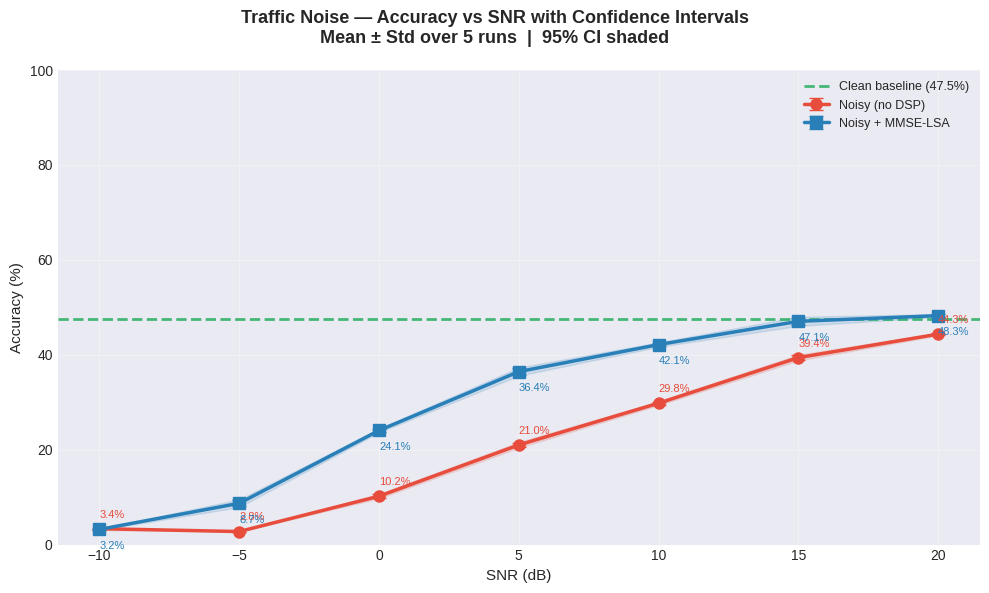

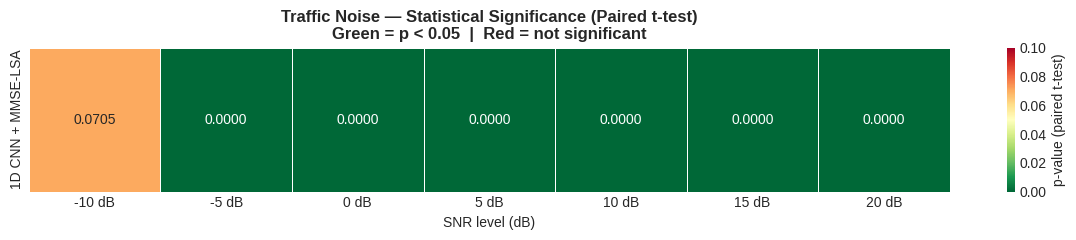


Per-run detail:
 SNR_dB  Run  Seed  Noisy_%  MMSE_%
    -10    1    42     3.50    3.25
    -10    2    43     3.50    3.25
    -10    3    44     3.25    3.25
    -10    4    45     3.00    3.00
    -10    5    46     3.50    3.25
     -5    1    42     2.75    9.25
     -5    2    43     2.75    9.50
     -5    3    44     2.75    8.00
     -5    4    45     2.75    8.25
     -5    5    46     2.75    8.50
      0    1    42    10.25   24.00
      0    2    43    10.75   24.25
      0    3    44    10.25   23.50
      0    4    45     9.75   24.25
      0    5    46    10.00   24.25
      5    1    42    21.50   37.25
      5    2    43    20.50   36.25
      5    3    44    21.25   37.00
      5    4    45    21.25   36.25
      5    5    46    20.50   35.50
     10    1    42    29.50   42.50
     10    2    43    30.25   41.75
     10    3    44    30.00   42.50
     10    4    45    29.75   42.25
     10    5    46    29.50   41.75
     15    1    42    39.25   47.75
     15    

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 16 — Traffic Statistical Detail (mean±std, 95%CI, paired t-test, heatmap)
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 16 · Traffic statistical detail — mean±std, 95%CI, paired t-test

stat_rows = []

stat_rows.append({
    "SNR_dB"      : "Clean",
    "Condition"   : "Clean Baseline",
    "Mean_Acc_%"  : round(baseline_acc * 100, 2),
    "Std_%"       : 0.0,
    "CI95_half_%" : 0.0,
    "Recovery_%"  : "—",
    "p_value"     : "—",
    "Significant" : "—",
})

for snr in TRAFFIC_SNR_LEVELS:
    na = np.array(results["_traffic_runs_noisy"][snr])
    da = np.array(results["_traffic_runs_denoised"][snr])

    if N_RUNS >= 2 and not np.allclose(na, da):
        _, p_val = ttest_rel(da, na)
        sig      = "Yes ✓" if p_val < 0.05 else "No"
    else:
        p_val, sig = float("nan"), "—"

    recovery = float(np.mean(da) - np.mean(na)) * 100

    for cond, arr in [("Noisy (no DSP)", na), ("Noisy + MMSE-LSA", da)]:
        stat_rows.append({
            "SNR_dB"      : snr,
            "Condition"   : cond,
            "Mean_Acc_%"  : round(np.mean(arr) * 100, 2),
            "Std_%"       : round(np.std(arr, ddof=1) * 100, 2) if N_RUNS > 1 else 0.0,
            "CI95_half_%" : round(ci95(arr) * 100, 2),
            "Recovery_%"  : round(recovery, 2) if "MMSE-LSA" in cond else "—",
            "p_value"     : round(p_val, 4) if not np.isnan(p_val) else "—",
            "Significant" : sig if "MMSE-LSA" in cond else "—",
        })

df_traffic_stats = pd.DataFrame(stat_rows)
traffic_csv = RESULTS_DIR / "traffic_statistics.csv"
df_traffic_stats.to_csv(str(traffic_csv), index=False)

print("\n" + "=" * 95)
print("  TRAFFIC NOISE — STATISTICAL DETAIL  |  1D CNN + MMSE-LSA")
print(f"  Runs: {N_RUNS}  |  Seeds: {SEEDS}  |  SNR levels: {TRAFFIC_SNR_LEVELS} dB")
print("=" * 95)
print(df_traffic_stats.to_string(index=False))
print("=" * 95)
print("  ✓ = paired t-test p < 0.05")
print(f"\n  Saved → {traffic_csv}")

# Traffic accuracy vs SNR with error bars and 95% CI shading
TR_COLORS = {"noisy": "#e74c3c", "denoised": "#2980b9", "clean": "#27ae60"}
snrs   = TRAFFIC_SNR_LEVELS
n_mean = [np.mean(results["_traffic_runs_noisy"][s])    * 100 for s in snrs]
n_std  = [np.std( results["_traffic_runs_noisy"][s],  ddof=1) * 100 for s in snrs]
d_mean = [np.mean(results["_traffic_runs_denoised"][s]) * 100 for s in snrs]
d_std  = [np.std( results["_traffic_runs_denoised"][s], ddof=1) * 100 for s in snrs]
n_ci   = [ci95(np.array(results["_traffic_runs_noisy"][s]))    * 100 for s in snrs]
d_ci   = [ci95(np.array(results["_traffic_runs_denoised"][s])) * 100 for s in snrs]

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(
    f"Traffic Noise — Accuracy vs SNR with Confidence Intervals\n"
    f"Mean ± Std over {N_RUNS} runs  |  95% CI shaded",
    fontsize=13, fontweight="bold")
ax.axhline(baseline_acc * 100, color=TR_COLORS["clean"], lw=2, ls="--",
           label=f"Clean baseline ({baseline_acc*100:.1f}%)", alpha=0.85)
ax.fill_between(snrs, np.array(n_mean)-np.array(n_ci),
                np.array(n_mean)+np.array(n_ci), alpha=0.15, color=TR_COLORS["noisy"])
ax.fill_between(snrs, np.array(d_mean)-np.array(d_ci),
                np.array(d_mean)+np.array(d_ci), alpha=0.15, color=TR_COLORS["denoised"])
ax.errorbar(snrs, n_mean, yerr=n_std, fmt="o-", color=TR_COLORS["noisy"],
            capsize=5, lw=2.5, ms=8, label="Noisy (no DSP)")
ax.errorbar(snrs, d_mean, yerr=d_std, fmt="s-", color=TR_COLORS["denoised"],
            capsize=5, lw=2.5, ms=8, label="Noisy + MMSE-LSA")
for s, nm, dm in zip(snrs, n_mean, d_mean):
    ax.annotate(f"{nm:.1f}%", (s, nm), textcoords="offset points",
                xytext=(0, 8),  fontsize=8, color=TR_COLORS["noisy"])
    ax.annotate(f"{dm:.1f}%", (s, dm), textcoords="offset points",
                xytext=(0,-14), fontsize=8, color=TR_COLORS["denoised"])
ax.set_xlabel("SNR (dB)", fontsize=11); ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_xticks(snrs); ax.set_ylim(0, 100)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "traffic_accuracy_ci.png"), dpi=150, bbox_inches="tight")
plt.show()

# p-value heatmap
p_vals = []
for snr in TRAFFIC_SNR_LEVELS:
    na = np.array(results["_traffic_runs_noisy"][snr])
    da = np.array(results["_traffic_runs_denoised"][snr])
    if N_RUNS >= 2 and not np.allclose(na, da):
        _, pv = ttest_rel(da, na)
    else:
        pv = float("nan")
    p_vals.append(pv)

p_matrix = np.array([p_vals])
fig, ax  = plt.subplots(figsize=(12, 2.5))
sns.heatmap(p_matrix, annot=True, fmt=".4f",
            cmap="RdYlGn_r", vmin=0, vmax=0.1,
            xticklabels=[f"{s} dB" for s in TRAFFIC_SNR_LEVELS],
            yticklabels=["1D CNN + MMSE-LSA"],
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "p-value (paired t-test)"})
ax.set_title("Traffic Noise — Statistical Significance (Paired t-test)\n"
             "Green = p < 0.05  |  Red = not significant",
             fontsize=12, fontweight="bold")
ax.set_xlabel("SNR level (dB)")
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "traffic_pvalue_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

# Per-run detail table + CSV
run_rows = []
for snr in TRAFFIC_SNR_LEVELS:
    for run_idx, run_seed in enumerate(SEEDS):
        run_rows.append({
            "SNR_dB"  : snr,
            "Run"     : run_idx + 1,
            "Seed"    : run_seed,
            "Noisy_%" : round(results["_traffic_runs_noisy"][snr][run_idx]    * 100, 2),
            "MMSE_%"  : round(results["_traffic_runs_denoised"][snr][run_idx] * 100, 2),
        })
df_runs  = pd.DataFrame(run_rows)
runs_csv = RESULTS_DIR / "traffic_per_run.csv"
df_runs.to_csv(str(runs_csv), index=False)
print("\nPer-run detail:")
print(df_runs.to_string(index=False))
print(f"\n  Saved → {runs_csv.name}")



17

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 17 — Grand Final Summary — All Noise Types
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell 17 · Grand final summary — all noise types

print("\n" + "═" * 80)
print("  GRAND FINAL SUMMARY — All Noise Types  |  1D CNN v2  |  MMSE-LSA")
print("═" * 80)
print(f"  Clean baseline: {baseline_acc*100:.2f}%\n")

# ── Synthetic noise (White / Gaussian / Low-SNR) ──────────────────────────────
print("  ── Synthetic Noise (MMSE-LSA) ─────────────────────────────────────────")
for noise_label, (nkey, dkey, snr_list) in {
        k: v for k, v in NOISE_CONFIGS.items() if k != "Traffic Noise"}.items():
    print(f"\n  {noise_label}:")
    for snr in snr_list:
        print(f"    {snr:>4}dB | Noisy: {results[nkey][snr]*100:.1f}%"
              f"  → DSP: {results[dkey][snr]*100:.1f}%"
              f"  | SNR gain: {results['snr_gain'][(nkey,snr)]:+.2f}dB")

# ── Traffic noise (multi-run stats) ──────────────────────────────────────────
print(f"\n  ── Real Traffic Noise (MMSE-LSA | {N_RUNS} runs, paired t-test) ─────────────")
print(f"  {'SNR':>6}  {'Noisy':>9}  {'±std':>6}  "
      f"{'MMSE-LSA':>9}  {'±std':>6}  {'Recovery':>10}  {'p-value':>9}")
print("  " + "─" * 65)
for snr in TRAFFIC_SNR_LEVELS:
    na  = np.array(results["_traffic_runs_noisy"][snr])
    da  = np.array(results["_traffic_runs_denoised"][snr])
    rec = (np.mean(da) - np.mean(na)) * 100
    if N_RUNS >= 2 and not np.allclose(na, da):
        _, pv = ttest_rel(da, na)
        sig = " ✓" if pv < 0.05 else "  "
    else:
        pv, sig = float("nan"), "  "
    print(f"  {snr:>4} dB  "
          f"{np.mean(na)*100:>7.2f}%  "
          f"{np.std(na, ddof=1)*100:>5.2f}%  "
          f"{np.mean(da)*100:>7.2f}%  "
          f"{np.std(da, ddof=1)*100:>5.2f}%  "
          f"{rec:>+9.2f}%  "
          f"{pv:>9.4f}{sig}")
print("  ✓ = statistically significant (p < 0.05)")

# ── DSP filter winner across all 4 noise types ───────────────────────────────
print(f"\n  ── DSP Winner: MMSE-LSA vs Butterworth+SS — All Noise Types ────────────")
for title, (nkey, dkey, snrs) in NOISE_CONFIGS_ALT.items():
    mmse_avg = np.mean([results[dkey][s]*100 for s in snrs])
    butt_avg = np.mean([results_alt[dkey][s]*100 for s in snrs])
    winner   = "MMSE-LSA" if mmse_avg > butt_avg else "Butterworth+SS"
    print(f"    {title:<20}  MMSE-LSA: {mmse_avg:.1f}%  |"
          f"  Butterworth+SS: {butt_avg:.1f}%  →  ✔ {winner}")

print(f"\n  All outputs saved to: {RESULTS_DIR}")
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
  GRAND FINAL SUMMARY — All Noise Types  |  1D CNN v2  |  MMSE-LSA
════════════════════════════════════════════════════════════════════════════════
  Clean baseline: 47.50%

  ── Synthetic Noise (MMSE-LSA) ─────────────────────────────────────────

  White Noise:
      20dB | Noisy: 37.0%  → DSP: 46.2%  | SNR gain: -8.80dB
      15dB | Noisy: 33.1%  → DSP: 43.5%  | SNR gain: -5.49dB
      10dB | Noisy: 23.0%  → DSP: 31.1%  | SNR gain: -2.16dB
       5dB | Noisy: 16.4%  → DSP: 22.3%  | SNR gain: +0.72dB
       0dB | Noisy: 10.2%  → DSP: 14.5%  | SNR gain: +3.14dB

  Gaussian Noise:
      20dB | Noisy: 37.0%  → DSP: 46.1%  | SNR gain: -8.77dB
      15dB | Noisy: 33.1%  → DSP: 43.4%  | SNR gain: -5.45dB
      10dB | Noisy: 23.2%  → DSP: 31.2%  | SNR gain: -2.16dB
       5dB | Noisy: 16.4%  → DSP: 22.2%  | SNR gain: +0.70dB
       0dB | Noisy: 10.5%  → DSP: 14.7%  | SNR gain: +3.15dB

  Low SNR:
       0dB | 

NameError: name 'NOISE_CONFIGS_ALT' is not defined